In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import re, collections
import seaborn as sns

ACCENT, GREY, LIGHT = "#1F6F8B", "#9AA8B3", "#C9D6DC"
PAIR = [ACCENT, GREY]
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (8, 4.2),
              "axes.spines.top": False, "axes.spines.right": False})

def hbar(data, y, x, ax, fmt="{:,.0f}", color=ACCENT):
    """Horizontal seaborn bar chart in the frame's order, with value labels."""
    sns.barplot(data=data, y=y, x=x, ax=ax, color=color, orient="h", order=list(data[y]))
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in data[x]], padding=3, fontsize=8)
    ax.set_xlim(0, data[x].max() * 1.18)
    ax.set_ylabel("")

def paired_share(data, cat, cols, names, ax):
    """Two percentage columns side by side per category (e.g. % repos vs % files)."""
    long = data.melt(id_vars=cat, value_vars=cols, var_name="measure", value_name="pct")
    long["measure"] = long.measure.map(dict(zip(cols, names)))
    sns.barplot(data=long, x=cat, y="pct", hue="measure", palette=PAIR, ax=ax, order=list(data[cat]))
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f", fontsize=8)
    ax.set_ylabel("%"); ax.legend(title="")

repos_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/repos/*.parquet'
artifacts_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/artifacts/*.parquet'
artifact_siblings_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/artifact_siblings/*.parquet'
mining_runs_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/mining_runs/*.parquet'
skill_features_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/generated_data/skill_features.parquet'
file_agents_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/generated_data/file_agents.parquet'

con = duckdb.connect(database=':memory:')

## Content and structure

Readable population and structural features of skill bodies.


In [ ]:
population = con.execute(f"""
SELECT COUNT(*)                                                    AS distinct_skills,
       COUNT_IF(content IS NULL OR content = '')                   AS no_text,
       COUNT_IF(strpos(content, chr(10)) = 0
                AND content LIKE '%SKILL.md')                      AS symlink_stubs,
       COUNT_IF(content LIKE 'Redirecting%')                       AS redirects,
       COUNT_IF(NOT frontmatter_valid)                             AS invalid_frontmatter,
       COUNT_IF(body_chars < 200)                                  AS short_body,
       COUNT_IF(first_commit_at < '2025-10-01')                    AS pre_format_history,
       COUNT_IF(content IS NOT NULL AND content <> ''
                AND NOT (strpos(content, chr(10)) = 0 AND content LIKE '%SKILL.md')
                AND content NOT LIKE 'Redirecting%'
                AND frontmatter_valid
                AND body_chars >= 200)                             AS kept
FROM read_parquet('{artifacts_path}')
WHERE dedup_primary = 1;
""").df()
population

,distinct_skills,no_text,symlink_stubs,redirects,invalid_frontmatter,short_body,pre_format_history,kept
0,1877981,0.0,5247.0,1.0,252280.0,37108.0,152.0,1601100.0


## Population

Of 1,877,981 distinct skills, none lack text. We remove 5,247 symlink stubs
(files whose content is only a path to another `SKILL.md`), one saved redirect
page, and skills with a body under 200 characters (placeholders and
front-matter-only files). Invalid YAML front matter affects 252,280 skills
(13.4%), far more than any other rule. Because broken front matter does not
make a file any less a skill, and validity is itself a potential authorship
signal, we report two populations: readable skills (quality filters only) and
valid skills (also requiring valid front matter, 1,601,100 or 85.3%). Each
analysis states which it uses.

In [7]:
invalid_fm = con.execute(f"""
SELECT CASE WHEN NOT regexp_matches(content, '^\\s*---')           THEN 'no front matter block'
            WHEN coalesce(name, '') = '' AND coalesce(description, '') = '' THEN 'block present, no name or description'
            WHEN coalesce(name, '') = ''                             THEN 'missing name'
            WHEN coalesce(description, '') = ''                      THEN 'missing description'
            ELSE 'other (YAML error or rule violation)' END AS reason,
       COUNT(*) AS skills, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM read_parquet('{artifacts_path}')
WHERE dedup_primary = 1 AND NOT frontmatter_valid
GROUP BY 1 ORDER BY skills DESC
""").df()
invalid_fm

,reason,skills,pct
0,no front matter block,171480,68.0
1,"block present, no name or description",49938,19.8
2,missing name,23060,9.1
3,missing description,7802,3.1


#### Structural features

Structural features of the readable population (deduplicated skills with a body of at least 200 characters, excluding symlink stubs and the saved redirect) are stored in `skill_features.parquet`. The summaries below cover length, markdown structure, and front-matter fields.


In [ ]:
structure = con.execute(f"""
SELECT COUNT(*)                                            AS skills,
       quantile_cont(body_words, [.1, .25, .5, .75, .9])  AS body_words_p10_p25_p50_p75_p90,
       quantile_cont(desc_chars, [.1, .5, .9])            AS desc_chars_p10_p50_p90,
       median(headings)                                    AS median_headings,
       ROUND(AVG((headings = 0)::INT), 3)                  AS share_no_headings,
       ROUND(AVG((numbered_items > 0)::INT), 3)            AS share_numbered_steps,
       ROUND(AVG((bullet_items > 0)::INT), 3)              AS share_bullets,
       ROUND(AVG((code_blocks > 0)::INT), 3)               AS share_code_blocks,
       ROUND(AVG((table_rows > 0)::INT), 3)                AS share_tables,
       ROUND(AVG((links > 0)::INT), 3)                     AS share_links,
       ROUND(AVG(has_examples_section::INT), 3)            AS share_examples_section,
       ROUND(AVG(has_when_to_use::INT), 3)                 AS share_when_to_use,
       ROUND(AVG(fm_allowed_tools::INT), 3)                AS share_fm_allowed_tools,
       ROUND(AVG(fm_license::INT), 3)                      AS share_fm_license,
       ROUND(AVG(fm_version_or_metadata::INT), 3)          AS share_fm_version_metadata,
       ROUND(AVG((non_ascii_ratio > 0.2)::INT), 3)         AS share_mostly_non_english
FROM '{skill_features_path}';
""").df()
structure.T.rename(columns={0: "value"})


,value
skills,1840872
body_words_p10_p25_p50_p75_p90,"[142.0, 306.0, 639.0, 1183.0, 1995.0]"
desc_chars_p10_p50_p90,"[0.0, 188.0, 478.0]"
median_headings,12.0
share_no_headings,0.017
share_numbered_steps,0.699
share_bullets,0.94
share_code_blocks,0.68
share_tables,0.442
share_links,0.205


In [ ]:
structure_by_location = con.execute(f"""
SELECT location_class, COUNT(*) AS skills,
       median(body_words)                          AS median_words,
       median(headings)                            AS median_headings,
       ROUND(AVG((code_blocks > 0)::INT), 3)       AS share_code_blocks,
       ROUND(AVG(has_examples_section::INT), 3)    AS share_examples_section,
       ROUND(AVG(has_when_to_use::INT), 3)         AS share_when_to_use
FROM '{skill_features_path}'
GROUP BY 1 ORDER BY skills DESC;
""").df()
structure_by_location


,location_class,skills,median_words,median_headings,share_code_blocks,share_examples_section,share_when_to_use
0,skills-dir,1019877,620.0,11.0,0.651,0.217,0.246
1,other,554589,636.0,13.0,0.690,0.245,0.293
2,canonical,266406,710.0,13.0,0.769,0.157,0.173


In [ ]:
body_length = con.execute(f"""
SELECT CASE WHEN body_words < 100 THEN '<100' WHEN body_words < 250 THEN '100-249'
            WHEN body_words < 500 THEN '250-499' WHEN body_words < 1000 THEN '500-999'
            WHEN body_words < 2000 THEN '1000-1999' WHEN body_words < 5000 THEN '2000-4999'
            ELSE '5000+' END AS words, MIN(body_words) AS sort_key, COUNT(*) AS skills
FROM '{skill_features_path}'
GROUP BY 1 ORDER BY sort_key;
""").df()
body_length


,words,sort_key,skills
0,<100,1,103867
1,100-249,100,267503
2,250-499,250,400665
3,500-999,500,491327
4,1000-1999,1000,394208
5,2000-4999,2000,159785
6,5000+,5000,23517


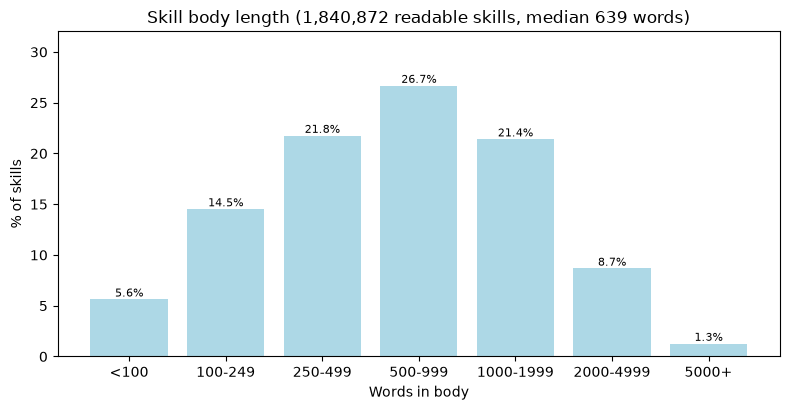

In [ ]:
body_length["pct"] = 100 * body_length.skills / body_length.skills.sum()

median_words = con.execute(f"SELECT median(body_words) FROM '{skill_features_path}'").fetchone()[0]

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(body_length.words, body_length.pct, color="lightblue")
ax.bar_label(bars, labels=[f"{p:.1f}%" for p in body_length.pct], fontsize=8)
ax.set_xlabel("Words in body"); ax.set_ylabel("% of skills")
ax.set_ylim(0, body_length.pct.max() * 1.2)
ax.set_title(f"Skill body length ({body_length.skills.sum():,} readable skills, median {median_words:.0f} words)")
plt.tight_layout()
plt.show()


#### Findings

On the readable population defined above (1,840,872 skills):

**Size.** A typical skill is a short document: the median body is 639 words,
with the middle half between 306 and 1,183 words. Seven in ten skills (70%)
fall between 250 and 2,000 words; 5.6% are under 100 words and 1.3% exceed
5,000. The median description is 188 characters, and at least 10% of skills
have none, mostly those with invalid front matter.

**Structure.** Skills are highly structured Markdown. The median skill has 12
headings, and only 1.7% have none. Most use bullet lists (94%), numbered steps
(70%) and code blocks (68%); 44% include tables and 21% link to other
resources. Structure is so common that its presence cannot distinguish one
kind of skill from another; its amount and organization might.

**Named sections.** Sections suggested by the skill format are less common
than generic structure: 22% have an Examples or Usage section and 25% a
"When to use" section spelling out the trigger conditions the description is
meant to convey.

**Front matter.** Beyond the required `name` and `description`, optional
fields are rare: `allowed-tools` appears in 9.6% of skills, `license` in 11.5%,
and `version` or `metadata` in 24.8%. Tool restrictions, which limit what an
agent may do while using a skill, are declared by fewer than one in ten.

**Language.** 7.4% of skills are mostly non-English, which matters for
text-similarity methods built on English-language models.

**By location.**

| Location | Skills | Median words | Code blocks | Examples section | "When to use" |
|---|---|---|---|---|---|
| Generic `skills/` | 1,019,877 | 620 | 65.1% | 21.7% | 24.6% |
| Other paths | 554,589 | 636 | 69.0% | 24.5% | 29.3% |
| Canonical agent folder | 266,406 | 710 | 76.9% | 15.7% | 17.3% |

Skills in canonical agent folders are longer and more code-heavy, but include
Examples and "When to use" sections less often. Skills in generic directories
more often come from published collections, which follow a fuller template
with explicit usage and trigger sections; skills written in place inside an
agent project are more working documents, with more code and less
presentation.

**Caveat.** Features are regex-based approximations; for example, a line
starting with `#` inside a code block counts as a heading.
